# ESTADÍSTICA INFERENCIAL

## MODELO PREDICTIVO

Como complemento al análisis exploratorio, probamos un modelo predictivo sencillo que refuerza los patrones observados previamente. No vamos a “adivinar quién se va”, sino a estimar el riesgo de Attrition y reforzar con evidencia cuantitativa los factores que ya vimos en el EDA.

### Objetivo del modelo predictivo

El objetivo de este modelo es estimar la probabilidad de rotación (Attrition) de los empleados a partir de variables relacionadas con el rol, la carga de trabajo y el contexto laboral, con el fin de apoyar la detección temprana de perfiles de riesgo y facilitar la toma de decisiones preventivas por parte de la empresa.

Este modelo tiene un propósito exploratorio y de apoyo a decisiones, no de despliegue en producción.

In [1]:
# LIBRERÍAS BÁSICAS
import pandas as pd
import numpy as np

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESADO Y MODELOS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# MÉTRICAS Y EVALUACIÓN
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ESTADÍSTICA INFERENCIAL
from scipy.stats import chi2_contingency

In [2]:
# Comprobación inicial

df = pd.read_csv("../files/hr_clean.csv")
df.columns

Index(['Unnamed: 0', 'age', 'attrition', 'business_travel', 'daily_rate',
       'department', 'distance_from_home', 'education', 'education_field',
       'employee_count', 'employee_number', 'environment_satisfaction',
       'gender', 'hourly_rate', 'job_involvement', 'job_level', 'job_role',
       'job_satisfaction', 'marital_status', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')

In [3]:
# La columna Unnamed: 0 corresponde al índice del DataFrame exportado al CSV,
# por lo que fue eliminada al no contener información relevante para el análisis ni para el modelo predictivo.

# Eliminar columna de índice residual
df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.columns

Index(['age', 'attrition', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field', 'employee_count',
       'employee_number', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')

#### PASO 1: DEFINICIÓN VARIABLE OBJETIVO (TARGET)

Para cualquier modelo predictivo se necesita una variable binaria numérica.

In [5]:
# Creación variable objetivo attrition_bin

# Variable objetivo binaria
df["attrition_bin"] = df["attrition"].map({"No": 0, "Yes": 1})

In [6]:
#Comprobación
df[["attrition", "attrition_bin"]].head()

,attrition,attrition_bin
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [7]:
# Revisión balance de clases
df["attrition_bin"].value_counts()
df["attrition_bin"].value_counts(normalize=True) * 100

attrition_bin
0    83.85346
1    16.14654
Name: proportion, dtype: float64

Para el modelo predictivo, transformamos la variable Attrition en una variable binaria, donde 1 indica abandono del empleado y 0 permanencia, lo que permite entrenar modelos de clasificación.

Dado el desbalance entre clases, se aplican técnicas de evaluación acordes al objetivo
de detección temprana del riesgo.

#### PASO 2: SELECCIÓN DE VARIABLES

CLAVE: Pocas variables, interpretables y alineadas con el EDA. 

Las variables seleccionadas se basan en los resultados del análisis exploratorio previo, priorizando aquellas que mostraron una mayor asociación con la rotación y que son fácilmente interpretables desde un punto de vista de negocio:

    1.- over_time → clave

    2.- business_travel → clave

    3.+ job_role → clave

    4.- job_level → contexto jerárquico

    5.- monthly_income → compensación

    6.-years_at_company → estabilidad

    7.- work_life_balance → percepción

Las variables seleccionadas combinan:

- Factores estructurales del puesto (job_role, job_level)
- Factores de carga laboral (over_time, business_travel)
- Factores económicos y de estabilidad (monthly_income, years_at_company)
- Factores de equilibrio personal (work_life_balance)

Esta selección se basa en los hallazgos del EDA y del análisis de interacciones previos.

#### PASO 3: DEFINIR x E y

In [8]:
features = [
    "over_time",
    "business_travel",
    "job_role",
    "job_level",
    "monthly_income",
    "years_at_company",
    "work_life_balance"
]

X = df[features].copy()
y = df["attrition_bin"].copy()

In [9]:
# Comprobación
X.head()
y.head()

0    1
1    0
2    1
3    0
4    0
Name: attrition_bin, dtype: int64

#### PASO 4: SEPARACIÓN EN TRAIN / TEST

Para evaluar la capacidad del modelo de generalizar a datos no vistos, separamos el dataset en un conjunto de entrenamiento y otro de test. Sin una separación entre entrenamiento y test no es posible evaluar la capacidad de generalización del modelo, por lo que cualquier métrica obtenida carecería de validez predictiva.

El parámetro `random_state` garantiza la reproducibilidad de los resultados.

In [10]:
# Realización del train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% para el conjunto de test (estándar)
    random_state=42,   # para reproducibilidad
    stratify=y        # como Attrition está desbalanceada, usamos stratify = y para mantener la proporción de clases en train y test
)

In [11]:
# Comprobación
y_train.value_counts(normalize=True) * 100
y_test.value_counts(normalize=True) * 100

attrition_bin
0    83.728814
1    16.271186
Name: proportion, dtype: float64

Dado el desbalance natural de la variable Attrition, se utiliza un muestreo estratificado para preservar la proporción de clases tanto en el conjunto de entrenamiento como en el de test.

Además, se fija una semilla aleatoria (random_state) para garantizar la reproducibilidad de los resultados y permitir su correcta validación.

El conjunto de test no sirve para mejorar el modelo, sino para evaluar si los patrones aprendidos en el entrenamiento se mantienen en datos no vistos.

#### PASO 5: PREPROCESADO + MODELO

El modelo mátemático no entiende de texto y tenemos variables categóricas y numéricas, por los que hay definir analíticamente de qué tipo es cada columna.

In [12]:
categorical_features = [
    "over_time",
    "business_travel",
    "job_role"
]

numeric_features = [
    "job_level",
    "monthly_income",
    "years_at_company",
    "work_life_balance"
]

In [13]:
# Creación del ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),    # Yes/No a 1/0
        ("num", "passthrough", numeric_features)                      # numéricas sin transformar   
    ]
)

In [14]:
# Elección del modelo: Regresión Logística
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"                 # para compensar el desbalanceo de clases (pocos "Yes")
)

In [15]:
# Unión del preprocesado y el modelo en un Pipeline “Cadena de pasos que garantiza que el preprocesado y el modelo se aplican siempre igual, 
# tanto en entrenamiento como en test.”
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

In [16]:
# Entrenamiento del modelo 
clf.fit(X_train, y_train)

c:\Users\gpsal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

El modelo se entrenó exclusivamente con el conjunto de entrenamiento, integrando el preprocesado y la regresión logística en un pipeline para evitar fugas de información y garantizar consistencia

ADVERTENCIA: Durante el entrenamiento se produjo un aviso de convergencia, habitual en modelos de regresión logística con variables categóricas y escalas heterogéneas. No afecta a la validez del modelo para el análisis exploratorio y la interpretación de patrones.

ConvergenceWarning: lbfgs failed to converge STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

¿Por qué pasa aquí? 

Hay tres razones muy típicas:

1.- Variables en escalas muy distintas

    monthly_income → miles

    job_level → 1–5

Eso dificulta la optimización.

2.- Muchas variables tras el OneHot

    job_role genera muchas columnas

    el espacio es grande

3.- Dataset realista (no de juguete)

#### PASO 6: EVALUACIÓN EN TEST

In [17]:
# 1.- Predecir sobre X_test
y_pred = clf.predict(X_test)

In [18]:
# 2.- Ver métricas: 
# a) Accuracy (porcentaje total de aciertos)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.6847457627118644

In [19]:
# b) Matriz de confusión [[TN modelo acierta FP modelo no acierta] [FN modelo no detecta TP modelo detecta]]
confusion_matrix(y_test, y_pred)

array([[171,  76],
       [ 17,  31]])

In [20]:
# c) Precisión, Recall y F1
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.69      0.79       247
           1       0.29      0.65      0.40        48

    accuracy                           0.68       295
   macro avg       0.60      0.67      0.59       295
weighted avg       0.81      0.68      0.72       295



### Lectura completa de los resultados

1️⃣ Accuracy = 0.68: El modelo acierta el 68 % de los casos en el conjunto de test. En problemas desbalanceados como attrition, la accuracy no es la métrica principal ni es suficiente por sí sola.

2️⃣ Matriz de confusión:

✅ 171 → empleados que NO se fueron y el modelo acierta

⚠️ 76 → falsas alarmas (el modelo dice que se van, pero no)

❌ 17 → empleados que se fueron y el modelo NO detectó

✅ 31 → empleados que se fueron y el modelo detectó

📌 Este número es el más delicado: 17 falsos negativos (personas que se van sin que el modelo lo vea)

3️⃣ Classification report:

🔹 Clase 0 (No se va)

precision: 0.91
recall:    0.69

El modelo es muy bueno identificando a quien NO se va. Normal en datasets desbalanceados.

🔹 Clase 1 (Sí se va → Attrition)

precision: 0.29
recall:    0.65
f1-score:  0.40
support:   48

👉 Esta es la lectura correcta, muy importante: 

    Recall = 0.65: El modelo detecta el 65 % de los empleados que realmente se van, lo que indica que el modelo identifica aproximadamente dos tercios de los empleados que abandonan la empresa.

✔️ Este comportamiento es adecuado para un escenario de detección temprana del riesgo, donde se prioriza minimizar los casos de abandono no detectados, incluso a costa de generar falsas alarmas.
✔️ Especialmente en un problema humano y complejo.

    Precision = 0.29: Solo el 29 % de los avisos del modelo son abandonos reales. Es decir: hay bastantes falsos positivos, pero eso es aceptable en este contexto.

📌 En attrition: Es preferible avisar de más que no detectar fugas reales.

### 3.- INTERPRETACIÓN de resultados con lectura de negocio

El modelo predictivo valida los patrones identificados en el análisis exploratorio y permite operacionalizarlos, facilitando la detección temprana de perfiles con mayor riesgo de rotación.

El modelo logra identificar aproximadamente dos tercios de los empleados que abandonan la empresa, aunque genera un número considerable de falsas alarmas (empleados clasificados como riesgo que finalmente no abandonan). Dado que el objetivo es la detección temprana del riesgo de rotación, este comportamiento es aceptable, ya que prioriza minimizar los casos de abandono no detectados.

Es un buen modelo exploratorio de predicción de riesgo y de apoyo a decisiones, no un modelo final de producción.

El modelo confirma que combinaciones de rol, carga horaria y contexto laboral permiten identificar perfiles con mayor probabilidad de abandono, lo que sugiere la necesidad de intervenciones específicas en estos colectivos.

### PASO 7: PROBABILIDADES, RIESGO Y SEGMENTACIÓN ACCIONABLE

#### ¿Quién tiene más riesgo y cuánto?

La regresión logística no piensa en “sí/no” internamente. Piensa en probabilidades.

Para cada empleado devuelve algo así:

    Probabilidad de NO irse: 0.72
    
    Probabilidad de SÍ irse: 0.28

In [30]:
# Obtener probabilidades en el conjunto TEST
y_prob = clf.predict_proba(X_test)

y_prob_attrition = y_prob[:, 1]     # Probabilidades de la clase positiva (Attrition = YES)

pd.Series(y_prob_attrition).describe()

count    295.000000
mean       0.416292
std        0.236849
min        0.027285
25%        0.204179
50%        0.394808
75%        0.604321
max        0.939518
dtype: float64

In [24]:
# Crear DataFrane de riesgo
risk_df = X_test.copy()
risk_df["prob_attrition"] = y_prob_attrition
risk_df["attrition_real"] = y_test.values
risk_df["attrition_pred"] = y_pred
risk_df.head()

,over_time,business_travel,job_role,job_level,monthly_income,years_at_company,work_life_balance,prob_attrition,attrition_real,attrition_pred
1398,No,Travel Frequently,Healthcare Representative,2,5968.0,9,3,0.224572,0,0
891,No,Travel Rarely,Research Scientist,1,2011.0,10,3,0.196917,0,0
456,No,Travel Rarely,Manager,3,11557.0,5,2,0.227232,0,0
922,No,Travel Rarely,Manager,5,19190.0,25,2,0.093935,0,0
711,Yes,Non Travel,Research Scientist,1,2404.0,0,3,0.656581,1,1


In [27]:
# Definición de umbral de riesgo (niveles)
def risk_level(p):
    if p >= 0.6:
        return "Alto"
    elif p >= 0.4:
        return "Medio"
    else:
        return "Bajo"

risk_df["risk_level"] = risk_df["prob_attrition"].apply(risk_level)
risk_df.head()

,over_time,business_travel,job_role,job_level,monthly_income,years_at_company,work_life_balance,prob_attrition,attrition_real,attrition_pred,risk_level
1398,No,Travel Frequently,Healthcare Representative,2,5968.0,9,3,0.224572,0,0,Bajo
891,No,Travel Rarely,Research Scientist,1,2011.0,10,3,0.196917,0,0,Bajo
456,No,Travel Rarely,Manager,3,11557.0,5,2,0.227232,0,0,Bajo
922,No,Travel Rarely,Manager,5,19190.0,25,2,0.093935,0,0,Bajo
711,Yes,Non Travel,Research Scientist,1,2404.0,0,3,0.656581,1,1,Alto


In [28]:
# Visualizaciones
pd.crosstab(
    risk_df["risk_level"],
    risk_df["job_role"],
    normalize="index"
) * 100

job_role,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
risk_level,,,,,,,,,
Alto,0.000000,5.333333,17.333333,1.333333,0.000000,0.000000,25.333333,22.666667,28.000000
Bajo,12.837838,0.675676,1.351351,13.513514,16.216216,12.837838,28.378378,14.189189,0.000000
Medio,5.555556,6.944444,40.277778,0.000000,11.111111,1.388889,13.888889,19.444444,1.388889


In [29]:
pd.crosstab(
    risk_df["risk_level"],
    risk_df["over_time"],
    normalize="index"
) * 100

over_time,No,Yes
risk_level,,
Alto,22.666667,77.333333
Bajo,96.621622,3.378378
Medio,73.611111,26.388889


In [31]:
# Para ver “dentro de OverTime=Yes, distribución de riesgo”
pd.crosstab(
    risk_df["over_time"],
    risk_df["risk_level"],
    normalize="index"
) * 100

risk_level,Alto,Bajo,Medio
over_time,,,
No,7.981221,67.136150,24.882629
Yes,70.731707,6.097561,23.170732


### OBSERVACIÓN

7 de cada 10 empleados que hacen horas extra están clasificados como riesgo alto por el modelo: Al segmentar por horas extra, se observa que el 70% de los empleados con OverTime activo se clasifican como riesgo alto, mientras que entre quienes no realizan horas extra predomina el riesgo bajo (67%). Esto confirma el papel del OverTime como principal factor estructural de riesgo de rotación.

IMPORTANTE: El modelo no se utiliza para clasificar empleados de forma determinista, sino para estimar niveles de riesgo que permitan priorizar intervenciones preventivas.

El modelo permite pasar de un análisis descriptivo a un enfoque preventivo, identificando niveles de riesgo de rotación y facilitando la priorización de acciones de RRHH

### INTERPRETACIÓN

Segmentación por riesgo (modelo predictivo): Al convertir las probabilidades del modelo en niveles de riesgo (alto/medio/bajo), se observa que el grupo de riesgo alto concentra una proporción notable de empleados con OverTime = Yes (≈77%). Además, ciertos roles como Sales Representative, Research Scientist y Laboratory Technician aparecen con mayor frecuencia dentro del segmento de riesgo alto. Esto refuerza los hallazgos del EDA y permite operacionalizar intervenciones preventivas focalizadas.

El OverTime actúa como un potente concentrador de riesgo: la mayoría de los empleados que realizan horas extra se sitúan en el nivel de riesgo alto, lo que sugiere que políticas de control de carga horaria pueden tener un impacto directo en la reducción de la rotación.

In [ ]:
# Comparativa
risk_df["risk_level"].value_counts(normalize=True) * 100

risk_level
Bajo     50.169492
Alto     25.423729
Medio    24.406780
Name: proportion, dtype: float64

In [33]:
risk_df.groupby("over_time")["risk_level"].value_counts(normalize=True) * 100


over_time  risk_level
No         Bajo          67.136150
           Medio         24.882629
           Alto           7.981221
Yes        Alto          70.731707
           Medio         23.170732
           Bajo           6.097561
Name: proportion, dtype: float64

### El modelo permite identificar que el riesgo de rotación no está distribuido de forma uniforme: se concentra de manera clara en los empleados con horas extra, especialmente en determinados roles, habilitando intervenciones preventivas focalizadas.

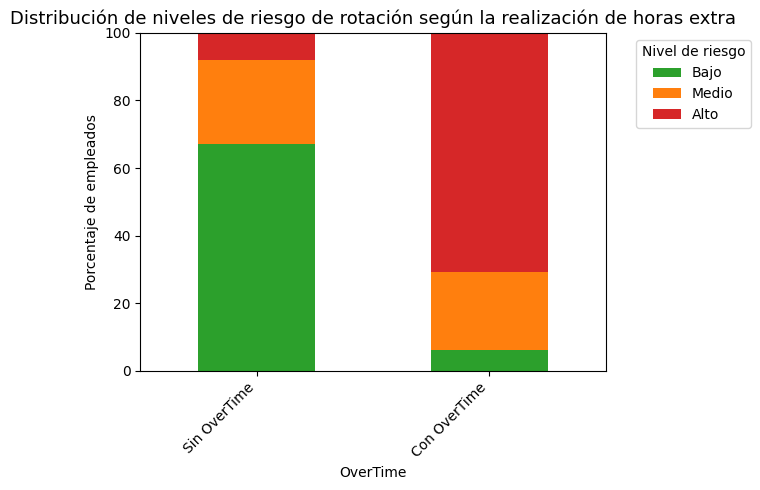

In [38]:
# Gráfico 1: barras apiladas por OverTime

risk_overtime = (
    risk_df
    .groupby("over_time")["risk_level"]
    .value_counts(normalize=True)
    .unstack() * 100
)

# Definir colores semánticos
colors = {
    "Bajo": "#2ca02c",    # verde
    "Medio": "#ff7f0e",   # naranja
    "Alto": "#d62728"     # rojo
}

# Orden lógico de los niveles
risk_overtime = risk_overtime[["Bajo", "Medio", "Alto"]]

# Crear gráfico
ax = risk_overtime.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5),
    color=[colors[c] for c in risk_overtime.columns]
)

# Títulos y etiquetas
ax.set_title("Distribución de niveles de riesgo de rotación según la realización de horas extra", fontsize=13)
ax.set_xlabel("OverTime")
ax.set_ylabel("Porcentaje de empleados")

plt.xticks(
    ticks=[0, 1],
    labels=["Sin OverTime", "Con OverTime"]
)

ax.legend(title="Nivel de riesgo", bbox_to_anchor=(1.05, 1), loc="upper left")

# Ajuste visual
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../outputs/modelo_predictivo/OverTime', bbox_inches='tight')
plt.show()

### Aquí utilizamos el modelo predictivo para clasificar a los empleados en niveles de riesgo. Observamos que, cuando no hay horas extra, la mayoría de empleados se concentran en riesgo bajo. Sin embargo, cuando existe OverTime, el perfil cambia radicalmente y más del 70% pasa a riesgo alto. Esto confirma que el OverTime actúa como un factor amplificador del riesgo de rotación

### Al introducir colores semánticos se observa claramente cómo el OverTime desplaza a la mayoría de empleados hacia niveles de riesgo alto, mientras que sin horas extra el riesgo predominante es bajo

Este gráfico resume todo el análisis. Cuando no hay horas extra, la mayoría de empleados se encuentra en riesgo bajo de rotación. Sin embargo, cuando aparece el OverTime, el patrón se invierte completamente: más del 70% de los empleados pasan a clasificarse como riesgo alto. Esto convierte al OverTime en un factor crítico para la toma de decisiones de RRHH

Este gráfico resume todo el análisis realizado: la realización de horas extra desplaza de forma estructural a los empleados hacia niveles altos de riesgo de rotación, confirmando que el OverTime es un factor clave de intervención prioritaria, ya que es un amplificador del riesgo.

#### ¿EN QUÉ ROLES PASA MÁS?

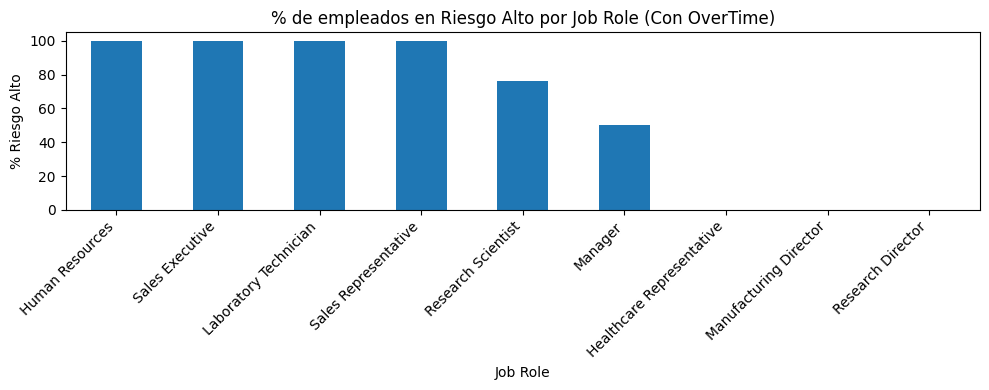

In [39]:
# Gráfico 2
df_ot_yes = risk_df[risk_df["over_time"] == "Yes"]

risk_high_by_role = (
    (df_ot_yes["risk_level"] == "Alto")
    .groupby(df_ot_yes["job_role"])
    .mean()
    * 100
).sort_values(ascending=False)

ax = risk_high_by_role.plot(kind="bar", figsize=(10,4))
plt.title("% de empleados en Riesgo Alto por Job Role (Con OverTime)")
plt.ylabel("% Riesgo Alto")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig('../outputs/modelo_predictivo/JobRole', bbox_inches='tight')
plt.show()

Estos porcentajes deben interpretarse junto al tamaño de cada colectivo, ya que algunos roles cuentan con un número reducido de empleados con OverTime. No obstante, el patrón observado es consistente con el análisis de interacciones previo.

## CONCLUSIONES del modelo predictivo

El modelo predictivo confirma y operacionaliza los patrones identificados en el análisis exploratorio,
permitiendo segmentar a los empleados según su nivel de riesgo de rotación.

Los resultados sugieren que la combinación de rol, carga horaria y contexto laboral
es clave para identificar perfiles críticos, especialmente en escenarios de horas extra.

Este enfoque permite a la empresa priorizar intervenciones preventivas y diseñar
acciones específicas orientadas a los colectivos con mayor riesgo.

## RECOMENDACIONES PARA LA EMPRESA

🎯 Objetivo

Reducir la rotación no deseada mediante intervenciones preventivas focalizadas, basadas en perfiles de riesgo identificados a partir del análisis de datos.

🔹 1. Priorización de colectivos de riesgo

Utilizar el modelo como herramienta de screening para identificar empleados con mayor probabilidad de abandono y priorizar acciones en colectivos específicos, especialmente aquellos donde confluyen:

realización de horas extra (OverTime = Yes),

determinados roles operativos y comerciales (p. ej. Sales Representative, Laboratory Technician),

contextos laborales exigentes (frecuencia de viajes, menor antigüedad).

📌 Valor: permite concentrar recursos de RRHH donde el impacto potencial es mayor.

🔹 2. Intervenciones específicas por rol

Dado que el impacto del OverTime no es homogéneo entre roles, se recomienda diseñar estrategias diferenciadas, por ejemplo:

revisión de cargas de trabajo y turnos en roles altamente sensibles al OverTime,

programas de rotación interna o desarrollo profesional en roles con riesgo estructural elevado,

refuerzo de medidas de conciliación en colectivos vulnerables.

📌 Valor: evita soluciones genéricas y mejora la eficacia de las políticas de retención.

🔹 3. Uso del modelo como sistema de alerta temprana

Integrar el modelo predictivo como una herramienta de apoyo, no automatizada, que permita:

detectar señales tempranas de riesgo,

iniciar conversaciones preventivas con empleados,

complementar el criterio experto de los equipos de RRHH.

📌 Valor: pasar de una gestión reactiva de la rotación a una gestión preventiva.

🔹 4. Evolución futura del modelo

Como siguientes pasos, se recomienda:

incorporar nuevas variables cualitativas (clima laboral, feedback, engagement),

recalibrar el modelo periódicamente con datos actualizados,

evaluar el impacto real de las intervenciones implementadas.

📌 Valor: convertir el análisis en un proceso vivo de mejora continua.

🧠 Cierre 

El análisis realizado demuestra que la rotación de empleados es un fenómeno multifactorial, pero identificable y parcialmente anticipable mediante el uso combinado de análisis exploratorio y modelos predictivos, lo que abre la puerta a decisiones de negocio más informadas y proactivas.